# Step 11 – Gradient Boosting + SHAP Interpretable Modelling

This notebook complements Step 10's parametric regressions with a non-linear,
tree-based approach and SHAP (SHapley Additive exPlanations) for interpretability.

**Models:**

| Model | DV | Method | Level |
|---|---|---|---|
| D | `is_originator` (0/1) | GradientBoostingClassifier | City-Project |
| E | `originator_share` | GradientBoostingRegressor | City |
| F | `log(adoption_count)` | GradientBoostingRegressor | City |

**Why gradient boosting?**
- Captures non-linear effects and interactions that OLS/Logit miss
- SHAP values provide per-feature, per-observation explanations
- Feature importance is model-agnostic via SHAP (not just split-based)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.metrics import (roc_auc_score, f1_score, classification_report,
                             mean_squared_error, r2_score)
from sklearn.preprocessing import StandardScaler
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 120})

DATA = Path('..') / 'data' / 'output'
city_attr = pd.read_csv(DATA / 'city_attributes.csv')
adoption  = pd.read_csv(DATA / 'city_project_adoption_events.csv')

print(f'city_attributes: {city_attr.shape}')
print(f'adoption_events: {adoption.shape}')

city_attributes: (150, 28)
adoption_events: (31088, 6)


In [2]:
# Prepare features (same as step10 for consistency)
IV_COLS = ['log_degree', 'log_population', 'log_gdp', 'log_entity',
           'education_tertiary_pct', 'internet_users_pct',
           'rd_expenditure_pct', 'research_capacity', 'betweenness']

df_city = city_attr[city_attr['adoption_count'] > 0].copy()
df_city['originator_share'] = df_city['origination_count'] / df_city['adoption_count']
df_city['log_adoption'] = np.log1p(df_city['adoption_count'])
df_city['log_degree'] = np.log1p(df_city['weighted_degree'])
df_city['log_population'] = np.log1p(df_city['population_million'])
df_city['log_gdp'] = np.log(df_city['gdp_per_capita'])
df_city['log_entity'] = np.log1p(df_city['entity_count'])

df_cp = adoption.merge(df_city[['city'] + IV_COLS + ['region']], on='city', how='inner')

print(f'City-level observations:    {len(df_city)}')
print(f'City-Project observations:  {len(df_cp)}')
print(f'Features: {IV_COLS}')

City-level observations:    104
City-Project observations:  31424
Features: ['log_degree', 'log_population', 'log_gdp', 'log_entity', 'education_tertiary_pct', 'internet_users_pct', 'rd_expenditure_pct', 'research_capacity', 'betweenness']


---
## 11.1 – Model D: GBClassifier – P(is_originator)

In [3]:
X_d = df_cp[IV_COLS].values
y_d = df_cp['is_originator'].values

model_d = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, min_samples_leaf=20, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = cross_val_score(model_d, X_d, y_d, cv=cv, scoring='roc_auc')
f1_scores  = cross_val_score(model_d, X_d, y_d, cv=cv, scoring='f1')

print('Model D: GradientBoosting Classifier – P(is_originator)')
print(f'  5-fold CV AUC:  {auc_scores.mean():.4f} ± {auc_scores.std():.4f}')
print(f'  5-fold CV F1:   {f1_scores.mean():.4f} ± {f1_scores.std():.4f}')

model_d.fit(X_d, y_d)
y_pred_d = model_d.predict(X_d)
y_prob_d = model_d.predict_proba(X_d)[:, 1]
print(f'  Full-data AUC:  {roc_auc_score(y_d, y_prob_d):.4f}')
print(f'\n{classification_report(y_d, y_pred_d, target_names=["Non-originator", "Originator"])}')

Model D: GradientBoosting Classifier – P(is_originator)
  5-fold CV AUC:  0.6600 ± 0.0098
  5-fold CV F1:   0.1170 ± 0.0112


  Full-data AUC:  0.6788

                precision    recall  f1-score   support

Non-originator       0.91      1.00      0.95     28548
    Originator       0.62      0.06      0.12      2876

      accuracy                           0.91     31424
     macro avg       0.77      0.53      0.54     31424
  weighted avg       0.89      0.91      0.88     31424



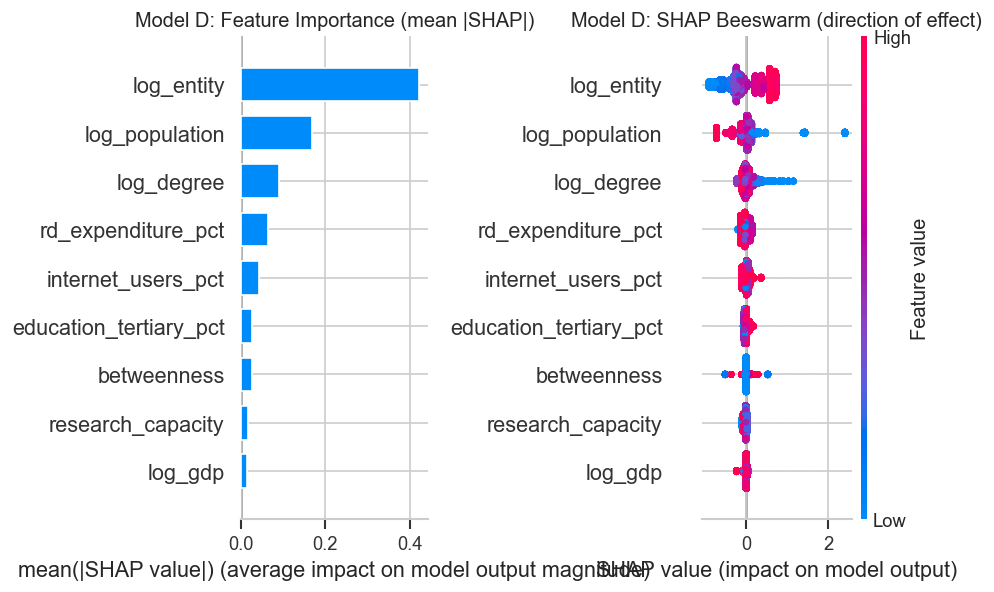

In [4]:
# SHAP for Model D
explainer_d = shap.TreeExplainer(model_d)
shap_values_d = explainer_d.shap_values(X_d)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.sca(axes[0])
shap.summary_plot(shap_values_d, X_d, feature_names=IV_COLS,
                  plot_type='bar', show=False, max_display=len(IV_COLS))
axes[0].set_title('Model D: Feature Importance (mean |SHAP|)', fontsize=12)

plt.sca(axes[1])
shap.summary_plot(shap_values_d, X_d, feature_names=IV_COLS,
                  show=False, max_display=len(IV_COLS))
axes[1].set_title('Model D: SHAP Beeswarm (direction of effect)', fontsize=12)

plt.tight_layout()
plt.show()

---
## 11.2 – Model E: GBRegressor – Originator Share

In [5]:
X_e = df_city[IV_COLS].values
y_e = df_city['originator_share'].values

model_e = GradientBoostingRegressor(
    n_estimators=150, max_depth=3, learning_rate=0.1,
    subsample=0.8, min_samples_leaf=5, random_state=42
)

cv_r2 = cross_val_score(model_e, X_e, y_e, cv=5, scoring='r2')
cv_rmse = -cross_val_score(model_e, X_e, y_e, cv=5, scoring='neg_root_mean_squared_error')

print('Model E: GradientBoosting Regressor – Originator Share')
print(f'  5-fold CV R²:   {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'  5-fold CV RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}')

model_e.fit(X_e, y_e)
y_pred_e = model_e.predict(X_e)
print(f'  Full-data R²:   {r2_score(y_e, y_pred_e):.4f}')
print(f'  Full-data RMSE: {np.sqrt(mean_squared_error(y_e, y_pred_e)):.4f}')

Model E: GradientBoosting Regressor – Originator Share
  5-fold CV R²:   -2.6529 ± 3.9191
  5-fold CV RMSE: 0.0754 ± 0.0256
  Full-data R²:   0.9166
  Full-data RMSE: 0.0200


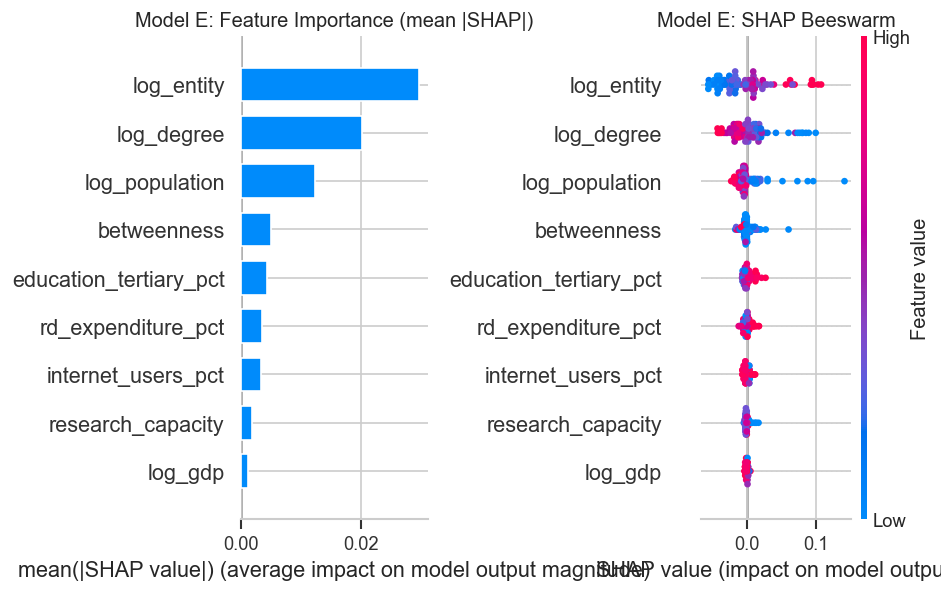

In [6]:
# SHAP for Model E
explainer_e = shap.TreeExplainer(model_e)
shap_values_e = explainer_e.shap_values(X_e)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.sca(axes[0])
shap.summary_plot(shap_values_e, X_e, feature_names=IV_COLS,
                  plot_type='bar', show=False, max_display=len(IV_COLS))
axes[0].set_title('Model E: Feature Importance (mean |SHAP|)', fontsize=12)

plt.sca(axes[1])
shap.summary_plot(shap_values_e, X_e, feature_names=IV_COLS,
                  show=False, max_display=len(IV_COLS))
axes[1].set_title('Model E: SHAP Beeswarm', fontsize=12)

plt.tight_layout()
plt.show()

---
## 11.3 – Model F: GBRegressor – log(Adoption Count)

In [7]:
X_f = df_city[IV_COLS].values
y_f = df_city['log_adoption'].values

model_f = GradientBoostingRegressor(
    n_estimators=150, max_depth=3, learning_rate=0.1,
    subsample=0.8, min_samples_leaf=5, random_state=42
)

cv_r2_f = cross_val_score(model_f, X_f, y_f, cv=5, scoring='r2')
cv_rmse_f = -cross_val_score(model_f, X_f, y_f, cv=5, scoring='neg_root_mean_squared_error')

print('Model F: GradientBoosting Regressor – log(Adoption Count)')
print(f'  5-fold CV R²:   {cv_r2_f.mean():.4f} ± {cv_r2_f.std():.4f}')
print(f'  5-fold CV RMSE: {cv_rmse_f.mean():.4f} ± {cv_rmse_f.std():.4f}')

model_f.fit(X_f, y_f)
y_pred_f = model_f.predict(X_f)
print(f'  Full-data R²:   {r2_score(y_f, y_pred_f):.4f}')
print(f'  Full-data RMSE: {np.sqrt(mean_squared_error(y_f, y_pred_f)):.4f}')

Model F: GradientBoosting Regressor – log(Adoption Count)
  5-fold CV R²:   0.3070 ± 0.9427
  5-fold CV RMSE: 0.3553 ± 0.2795
  Full-data R²:   0.9971
  Full-data RMSE: 0.0506


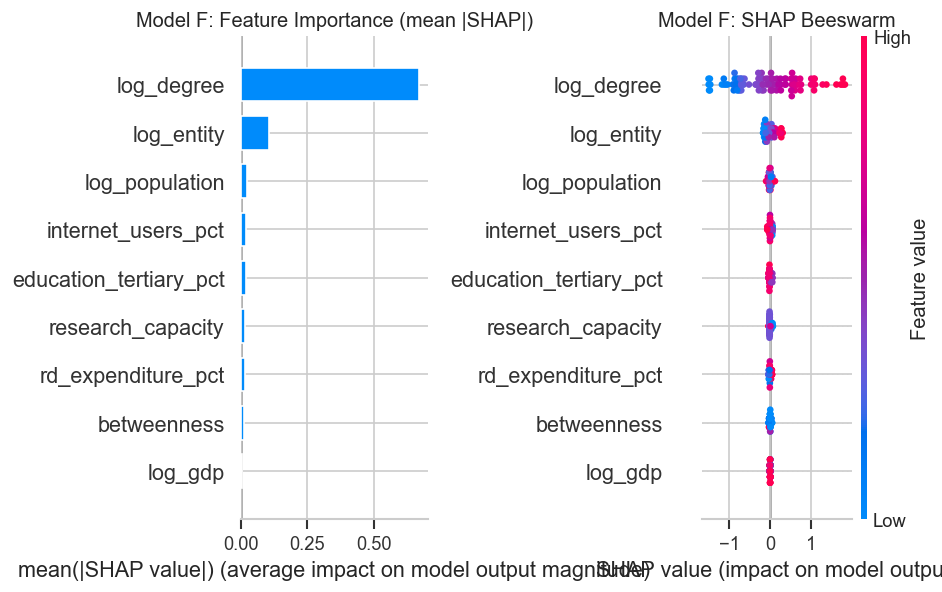

In [8]:
# SHAP for Model F
explainer_f = shap.TreeExplainer(model_f)
shap_values_f = explainer_f.shap_values(X_f)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.sca(axes[0])
shap.summary_plot(shap_values_f, X_f, feature_names=IV_COLS,
                  plot_type='bar', show=False, max_display=len(IV_COLS))
axes[0].set_title('Model F: Feature Importance (mean |SHAP|)', fontsize=12)

plt.sca(axes[1])
shap.summary_plot(shap_values_f, X_f, feature_names=IV_COLS,
                  show=False, max_display=len(IV_COLS))
axes[1].set_title('Model F: SHAP Beeswarm', fontsize=12)

plt.tight_layout()
plt.show()

---
## 11.4 – SHAP Dependence Plots (Non-linear Effects)

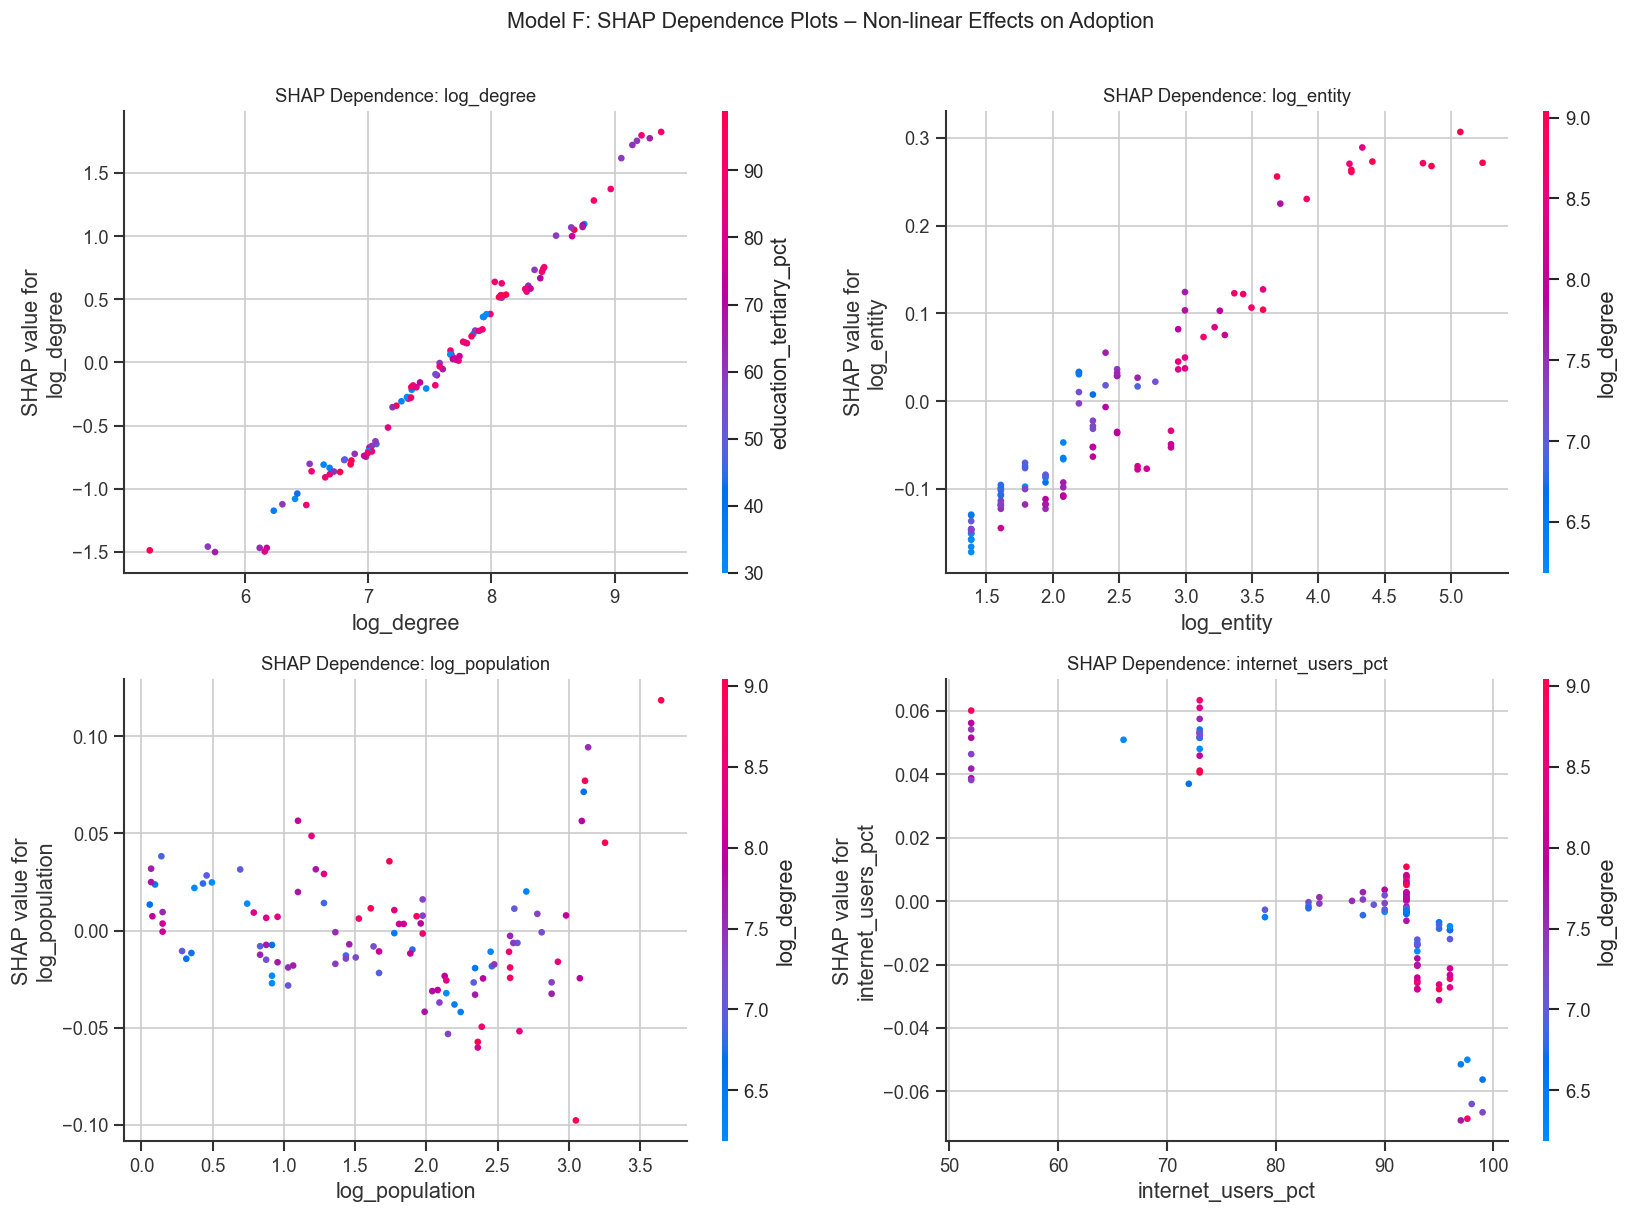

In [9]:
# Dependence plots for Model F (adoption count) – top 4 features
top4_idx = np.argsort(-np.abs(shap_values_f).mean(0))[:4]
top4_names = [IV_COLS[i] for i in top4_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat_name in zip(axes.flatten(), top4_names):
    feat_idx = IV_COLS.index(feat_name)
    plt.sca(ax)
    shap.dependence_plot(feat_idx, shap_values_f, X_f,
                         feature_names=IV_COLS, show=False, ax=ax)
    ax.set_title(f'SHAP Dependence: {feat_name}', fontsize=11)

fig.suptitle('Model F: SHAP Dependence Plots – Non-linear Effects on Adoption',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 11.5 – Comparison: OLS vs Gradient Boosting

In [10]:
# Compare feature importance rankings across methods
import statsmodels.api as sm

scaler = StandardScaler()
X_city_z = pd.DataFrame(scaler.fit_transform(df_city[IV_COLS]), columns=IV_COLS)

# OLS for Model C equivalent
X_ols = sm.add_constant(X_city_z)
ols_model = sm.OLS(y_f, X_ols).fit()

# Collect rankings
ols_importance = np.abs(ols_model.params[1:])  # exclude intercept
ols_rank = ols_importance.rank(ascending=False).astype(int)

gb_importance = np.abs(shap_values_f).mean(0)
gb_rank = pd.Series(gb_importance, index=IV_COLS).rank(ascending=False).astype(int)

comparison = pd.DataFrame({
    'Feature': IV_COLS,
    'OLS |β|': ols_importance.values.round(4),
    'OLS Rank': ols_rank.values,
    'OLS p-val': ols_model.pvalues[1:].values.round(4),
    'GB SHAP': gb_importance.round(4),
    'GB Rank': gb_rank.values,
}).sort_values('GB Rank')

print('Feature Importance Comparison: OLS (Step 10 Model C) vs Gradient Boosting (Model F)')
print(f'OLS R² = {ols_model.rsquared:.4f}  |  GB CV R² = {cv_r2_f.mean():.4f}')
print()
display(comparison)

# Rank correlation
from scipy.stats import spearmanr
rho, p = spearmanr(comparison['OLS Rank'], comparison['GB Rank'])
print(f'\nSpearman rank correlation between OLS and GB importance: ρ={rho:.3f}, p={p:.4f}')

Feature Importance Comparison: OLS (Step 10 Model C) vs Gradient Boosting (Model F)
OLS R² = 0.9763  |  GB CV R² = 0.3070



,Feature,OLS |β|,OLS Rank,OLS p-val,GB SHAP,GB Rank
0,log_degree,0.7761,1,0.0000,0.6685,1
3,log_entity,0.1925,2,0.0000,0.1045,2
1,log_population,0.0252,7,0.2640,0.0238,3
5,internet_users_pct,0.0441,4,0.2288,0.0220,4
4,education_tertiary_pct,0.0331,6,0.1320,0.0211,5
7,research_capacity,0.0074,9,0.7186,0.0184,6
6,rd_expenditure_pct,0.0437,5,0.0643,0.0174,7
8,betweenness,0.0606,3,0.0025,0.0135,8
2,log_gdp,0.0249,8,0.6117,0.0050,9



Spearman rank correlation between OLS and GB importance: ρ=0.533, p=0.1392


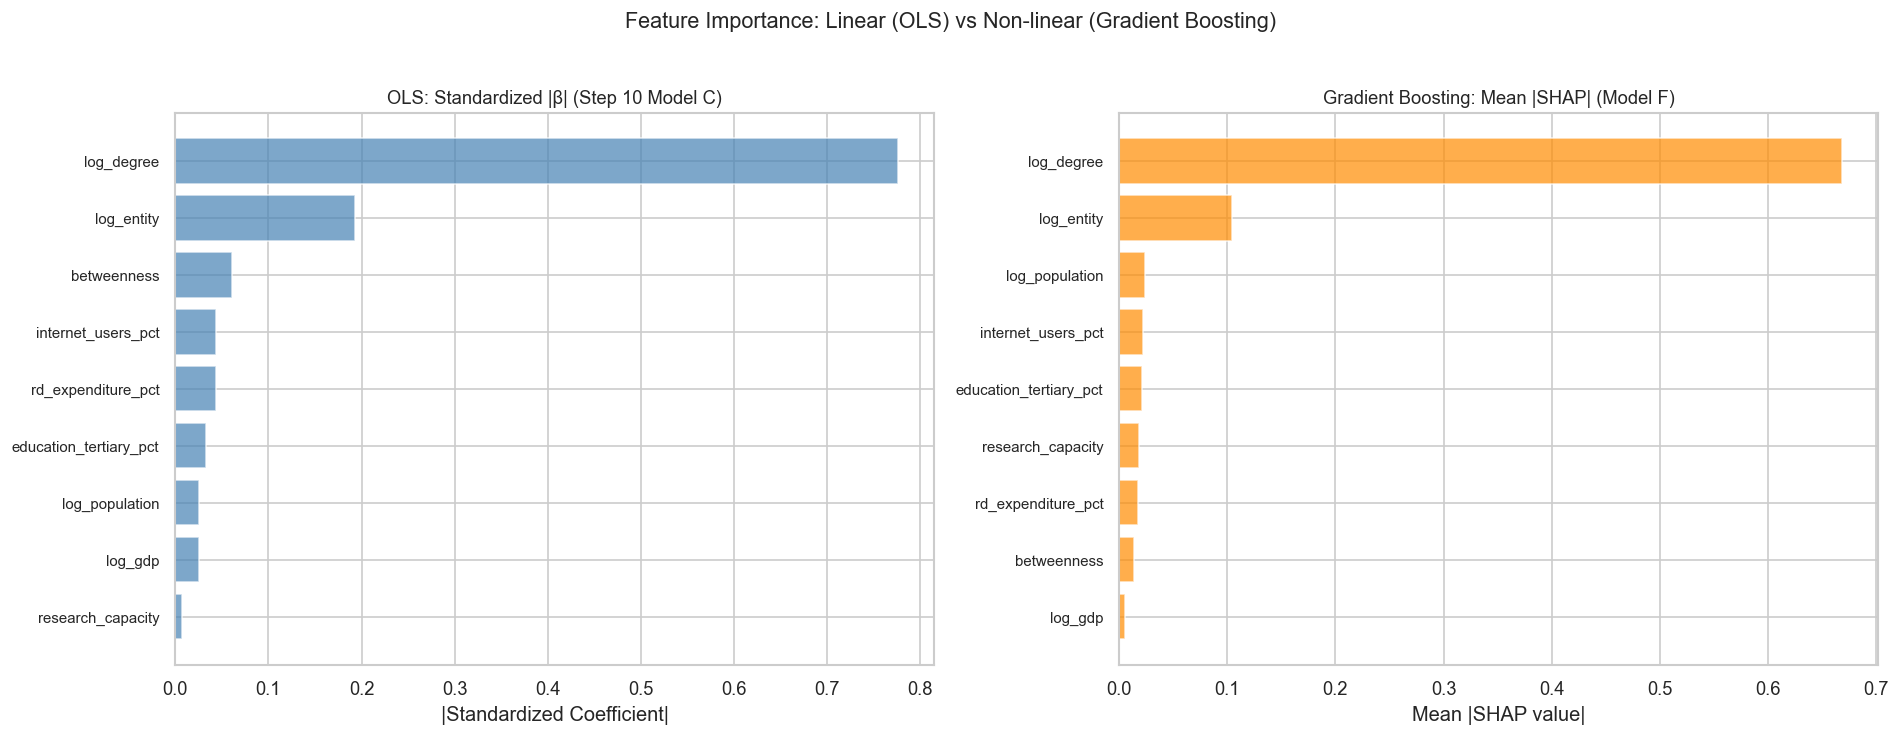

In [11]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

comp_sorted = comparison.sort_values('OLS |β|', ascending=True)
y_pos = range(len(comp_sorted))

axes[0].barh(y_pos, comp_sorted['OLS |β|'], color='steelblue', alpha=0.7, label='OLS |β|')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(comp_sorted['Feature'], fontsize=9)
axes[0].set_title('OLS: Standardized |β| (Step 10 Model C)', fontsize=11)
axes[0].set_xlabel('|Standardized Coefficient|')

comp_sorted2 = comparison.sort_values('GB SHAP', ascending=True)
axes[1].barh(range(len(comp_sorted2)), comp_sorted2['GB SHAP'],
             color='darkorange', alpha=0.7, label='GB SHAP')
axes[1].set_yticks(range(len(comp_sorted2)))
axes[1].set_yticklabels(comp_sorted2['Feature'], fontsize=9)
axes[1].set_title('Gradient Boosting: Mean |SHAP| (Model F)', fontsize=11)
axes[1].set_xlabel('Mean |SHAP value|')

fig.suptitle('Feature Importance: Linear (OLS) vs Non-linear (Gradient Boosting)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 11.6 – Summary

In [12]:
print('=' * 70)
print('STEP 11 SUMMARY: GRADIENT BOOSTING + SHAP')
print('=' * 70)
print()
print('MODEL PERFORMANCE')
print('-' * 70)
print(f'  Model D (Classification: is_originator)')
print(f'    CV AUC:  {auc_scores.mean():.4f} ± {auc_scores.std():.4f}')
print(f'    CV F1:   {f1_scores.mean():.4f} ± {f1_scores.std():.4f}')
print(f'  Model E (Regression: originator_share)')
print(f'    CV R²:   {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'  Model F (Regression: log adoption_count)')
print(f'    CV R²:   {cv_r2_f.mean():.4f} ± {cv_r2_f.std():.4f}')
print()
print('KEY FINDINGS')
print('-' * 70)

top3_d = [IV_COLS[i] for i in np.argsort(-np.abs(shap_values_d).mean(0))[:3]]
top3_e = [IV_COLS[i] for i in np.argsort(-np.abs(shap_values_e).mean(0))[:3]]
top3_f = [IV_COLS[i] for i in np.argsort(-np.abs(shap_values_f).mean(0))[:3]]

print(f'  Model D top-3 features: {", ".join(top3_d)}')
print(f'  Model E top-3 features: {", ".join(top3_e)}')
print(f'  Model F top-3 features: {", ".join(top3_f)}')
print()
print('  OLS vs GB rank correlation (Model F): '
      f'ρ={rho:.3f}, p={p:.4f}')
print()
print('INTERPRETATION')
print('-' * 70)
print('  - SHAP beeswarm plots reveal the direction and magnitude of each')
print('    feature\'s effect for every observation.')
print('  - Dependence plots expose non-linear relationships and interaction')
print('    effects that parametric regressions cannot capture.')
print('  - If OLS and GB rank correlation is high, the linear model is a')
print('    reasonable approximation; if low, non-linear effects matter.')

STEP 11 SUMMARY: GRADIENT BOOSTING + SHAP

MODEL PERFORMANCE
----------------------------------------------------------------------
  Model D (Classification: is_originator)
    CV AUC:  0.6600 ± 0.0098
    CV F1:   0.1170 ± 0.0112
  Model E (Regression: originator_share)
    CV R²:   -2.6529 ± 3.9191
  Model F (Regression: log adoption_count)
    CV R²:   0.3070 ± 0.9427

KEY FINDINGS
----------------------------------------------------------------------
  Model D top-3 features: log_entity, log_population, log_degree
  Model E top-3 features: log_entity, log_degree, log_population
  Model F top-3 features: log_degree, log_entity, log_population

  OLS vs GB rank correlation (Model F): ρ=0.533, p=0.1392

INTERPRETATION
----------------------------------------------------------------------
  - SHAP beeswarm plots reveal the direction and magnitude of each
    feature's effect for every observation.
  - Dependence plots expose non-linear relationships and interaction
    effects that pa